# STAT443 ILI — Rolling One-Step-Ahead Forecasting
Karl Estampador

This notebook implements:
1. Rolling (expanding-window) one-step-ahead evaluation for all baseline + ARIMA models
2. Covariate lag analysis for age-group variables
3. ARIMAX with lagged age-group covariates
4. Residual diagnostics (ACF/PACF)

## TLDR of what to include in the report:

### Section 1: Introduction

**Goals:** Forecast weekly U.S. national percent weighted ILI using CDC FluView data (2002–2021), and compare out-of-sample one-step-ahead RMSE across four model classes:
(a) simple baselines (persistence / training mean),
(b) exponential smoothing (STL + ETS),
(c) ARIMA without explanatory variables,
(d) ARIMAX with lagged age-group covariates.

**Main conclusions:**

- **Simple baselines** — the training mean (RMSE = 1.53) and seasonal naïve (RMSE = 2.06) served as the lower and upper benchmark anchors respectively. Both were easily beaten by the time-series models.
- **STL + ETS** (exponential smoothing via STL decomposition + damped additive trend ETS) achieved RMSE = 0.376. Note: ETS ignores seasonality for period > 24 (period = 52 here), so the seasonal structure is handled entirely by the STL component — worth stating as a limitation. Instead, ETS fits a damped additive trend on deseasonalized component, which is a known constraint of ETS implementations.
- **ARIMA(2,0,2)(2,1,0)[52]** was the winning model by holdout RMSE = 0.270. It outperformed all other candidates including ARIMAX.
- **ARIMAX — LM w/ ARIMA(2,0,1)(1,1,0)[52] errors** — achieved RMSE = 0.378, narrowly beating STL+ETS but worse than ARIMA. While ARIMAX produced a slightly lower AIC (371.09 vs. 380.49 for ARIMA), its regressor coefficients were all near zero (e.g., d_age_65_lag1 = −0.0001), and several standard errors could not be computed (NaN). This suggests lagged age-group differences add little or no predictive power beyond what the ILI series itself already captures. The NaN standard errors also indicate a near-singular covariance matrix, flagging multicollinearity or redundancy among the covariates.
- **Winning model:** ARIMA(2,0,2)(2,1,0)[52] with holdout RMSE = 0.270.

---

### Section 2: Variable Selection

**Variables:**

- **Response:** `percent_weighted_ili` — national weekly percentage of patient visits flagged as ILI, 2002 W01 to 2021 W52 (1,044 weeks after deduplication).
- **Covariates:** age-group ILI counts — `age_0_4`, `age_5_24`, `age_25_49`, `age_50_64`, `age_65` (all in raw patient counts per week).

**Data notes to mention:**

- 3 duplicate `week_start` rows resolved by within-week averaging.
- 384 rows (pre-2010) had missing `age_25_49` / `age_50_64` — imputed as `age_25_64 / 2` since the breakdown was not collected before that era. Flag as a limitation.
- 3 remaining NAs per age column after imputation; `percent_weighted_ili` NAs linearly interpolated.

**What to include:**

- Time plot of `percent_weighted_ili` (strong annual seasonality visible; COVID disruption visible in 2020 as a sharp drop).
- ACF/PACF plots of the raw series and of first differences (to motivate differencing decisions and AR/MA order selection).
- CCF plots of differenced age-group series vs. differenced ILI at lags −8 to +8 — negative lags indicate leading predictors. Analysis found `age_5_24` had the strongest signal at lag −1 (CCF = 0.585), followed by `age_0_4` (0.422), `age_25_49` (0.304), `age_50_64` (0.288), and `age_65` (0.156). Hence, we selected `age_5_24` as the leading covariate in the final ARIMAX model.
- Summary statistics table: mean, SD, min, max for `percent_weighted_ili` and each age column (one decimal beyond the raw data per the rubric).
- **Train/holdout split:** last 104 weeks held out (2020 W02 – 2021 W52), initial training on 938 weeks. This covers two full flu seasons in the holdout, including the COVID-affected 2020 season — a deliberate and noteworthy stress test for the models.

---

### Section 3: Analysis

**Outline of analyses supporting the main conclusions:**

1. **Baseline models** — MEAN and SNAIVE(lag = 52) fit via expanding-window rolling evaluation. These establish the floor: any useful model must substantially beat RMSE ≈ 1.5–2.1.

2. **Exponential smoothing** — STL decomposition (period = 52) followed by damped additive ETS on the seasonally adjusted component. Report the ETS-ignores-seasonality-for-period > 24 warning and explain how STL mitigates it. RMSE = 0.376.

3. **ARIMA model selection** — auto-selected on full training data as ARIMA(2,0,2)(2,1,0)[52]. Report model coefficients, AIC = 380.49, and residual diagnostics (ACF/PACF of residuals, residual histogram). No unit root / differencing needed for the non-seasonal component; one seasonal difference applied. Rolling holdout RMSE = 0.270.

4. **ARIMAX covariate selection** — CCF analysis (differenced series) used to identify leading covariates. All five lagged age-group differences included; auto-selection chose ARIMA(2,0,1)(1,1,0)[52] errors. Report near-zero regressor coefficients and NaN standard errors as evidence of redundancy. AIC = 371.09 (lower than ARIMA) but holdout RMSE = 0.378 (worse). Discuss the AIC vs. RMSE discrepancy as a key finding: lower AIC does not guarantee better out-of-sample performance when regressors are near-collinear with the response.

5. **Residual diagnostics** — `gg_tsresiduals()` plots for both ARIMA and ARIMAX (time plot of residuals, ACF up to lag 52, histogram). Confirm approximate white noise in ARIMA residuals; note any residual autocorrelation in ARIMAX.

6. **Model comparison summary** — present the RMSE table ranked by holdout performance:

| Model    | Holdout RMSE | n  |
|----------|--------------|----|
| ARIMA    | 0.270        | 104 |
| STL+ETS  | 0.376        | 104 |
| ARIMAX   | 0.378        | 104 |
| Mean     | 1.53         | 104 |
| SNaive   | 2.06         | 104 |

   Conclude that ARIMA(2,0,2)(2,1,0)[52] is the recommended model. Discuss the COVID holdout window as a potential confounder — the sharp drop in ILI in 2020 likely inflates errors for seasonality-heavy models like SNaive and challenges all models calibrated on pre-pandemic flu patterns.

In [1]:
# install.packages(c(
#   "tidyverse","readr","janitor","lubridate","ISOweek",
#   "forecast","fable","fabletools","tsibble","feasts",
#   "slider","here", "skimr", "naniar", "tsibble", "feasts"
# ))

In [2]:
library(tidyverse)
library(tsibble)
library(fable)
library(fabletools)
library(feasts)
library(lubridate)

options(repr.plot.width = 12, repr.plot.height = 5, repr.plot.res = 150)

Warning message:
"package 'tidyverse' was built under R version 4.5.3"
Warning message:
"package 'ggplot2' was built under R version 4.5.3"
Warning message:
"package 'tibble' was built under R version 4.5.3"
Warning message:
"package 'tidyr' was built under R version 4.5.3"
Warning message:
"package 'readr' was built under R version 4.5.3"
Warning message:
"package 'purrr' was built under R version 4.5.3"
Warning message:
"package 'dplyr' was built under R version 4.5.3"
Warning message:
"package 'stringr' was built under R version 4.5.2"
Warning message:
"package 'forcats' was built under R version 4.5.2"
Warning message:
"package 'lubridate' was built under R version 4.5.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────

## 1) Load and prepare data

In [3]:
# Load the cleaned data
ilinet_raw <- readr::read_csv(
  "fluview_clean/ilinet_clean.csv",
  na           = c("NA", "", "X"),
  show_col_types = FALSE
)

# Keep national rows, filter to 2002-2021 per proposal
df_raw <- ilinet_raw %>%
  filter(
    region_type == "National",
    year >= 2002, year <= 2021
  ) %>%
  arrange(week_start) %>%
  select(week_start, percent_weighted_ili,
         age_0_4, age_5_24, age_25_49, age_25_64, age_50_64, age_65) %>%
  mutate(week_start = as.Date(week_start))  # ensure proper Date type

# Handle duplicate week_start dates
n_dups <- sum(duplicated(df_raw$week_start))
if (n_dups > 0) {
  message(n_dups, " duplicate week_start row(s) found — averaging within each date.")
  df_raw <- df_raw %>%
    group_by(week_start) %>%
    summarise(across(where(is.numeric), \(x) mean(x, na.rm = TRUE)),
              .groups = "drop") %>%
    arrange(week_start)
}

# Impute age_25_49 / age_50_64 for pre-2010 rows
n_imputed <- sum(is.na(df_raw$age_25_49))
if (n_imputed > 0) {
  message(n_imputed, " rows imputed: age_25_49 = age_50_64 = age_25_64 / 2")
  df_raw <- df_raw %>%
    mutate(
      age_25_49 = if_else(is.na(age_25_49), age_25_64 / 2, age_25_49),
      age_50_64 = if_else(is.na(age_50_64), age_25_64 / 2, age_50_64)
    )
}

# building a tsibble
df <- df_raw %>%
  select(week_start, percent_weighted_ili,
         age_0_4, age_5_24, age_25_49, age_50_64, age_65) %>%
  mutate(week_start = tsibble::yearweek(week_start)) %>%
  as_tsibble(index = week_start) %>%
  fill_gaps()  # make any missing weeks explicit (NA rows) — required by fable

if (any(is.na(df$percent_weighted_ili))) {
  x <- as.numeric(df$week_start)
  y <- df$percent_weighted_ili
  df$percent_weighted_ili <- stats::approx(
    x = x[!is.na(y)], y = y[!is.na(y)],
    xout = x, method = "linear", rule = 2
  )$y
}

cat("Rows:", nrow(df), "\n")
cat("Range:", as.character(min(df$week_start)),
    "to", as.character(max(df$week_start)), "\n")
cat("Remaining NAs in age columns:\n")
print(colSums(is.na(select(df, starts_with("age_")))))

3 duplicate week_start row(s) found — averaging within each date.

384 rows imputed: age_25_49 = age_50_64 = age_25_64 / 2



Rows: 1044 
Range: 2002 W01 to 2021 W52 
Remaining NAs in age columns:
   age_0_4   age_5_24  age_25_49  age_50_64     age_65 week_start 
         3          3          3          3          3          0 


In [4]:
## 1b) Summary statistics

summary_stats <- df %>%
  as_tibble() %>%
  select(percent_weighted_ili, age_0_4, age_5_24, age_25_49, age_50_64, age_65) %>%
  summarise(across(
    everything(),
    list(
      mean = ~round(mean(.x, na.rm = TRUE), 1),
      sd   = ~round(sd(.x,   na.rm = TRUE), 1),
      min  = ~round(min(.x,  na.rm = TRUE), 1),
      max  = ~round(max(.x,  na.rm = TRUE), 1)
    ),
    .names = "{.col}__{.fn}"
  )) %>%
  pivot_longer(
    everything(),
    names_to  = c("variable", "stat"),
    names_sep = "__"
  ) %>%
  pivot_wider(names_from = stat, values_from = value)

print(summary_stats)

# A tibble: 6 × 5
  variable               mean     sd   min     max
  <chr>                 <dbl>  <dbl> <dbl>   <dbl>
1 percent_weighted_ili    1.8    1.3     0     7.7
2 age_0_4              3605.  3503.      0 24109  
3 age_5_24             5033.  6016.      0 45491  
4 age_25_49            2993.  4189       0 38300  
5 age_50_64            1389.  1644.      0 13512  
6 age_65                895   1125.      0  8989  


## 2) Covariate lag analysis

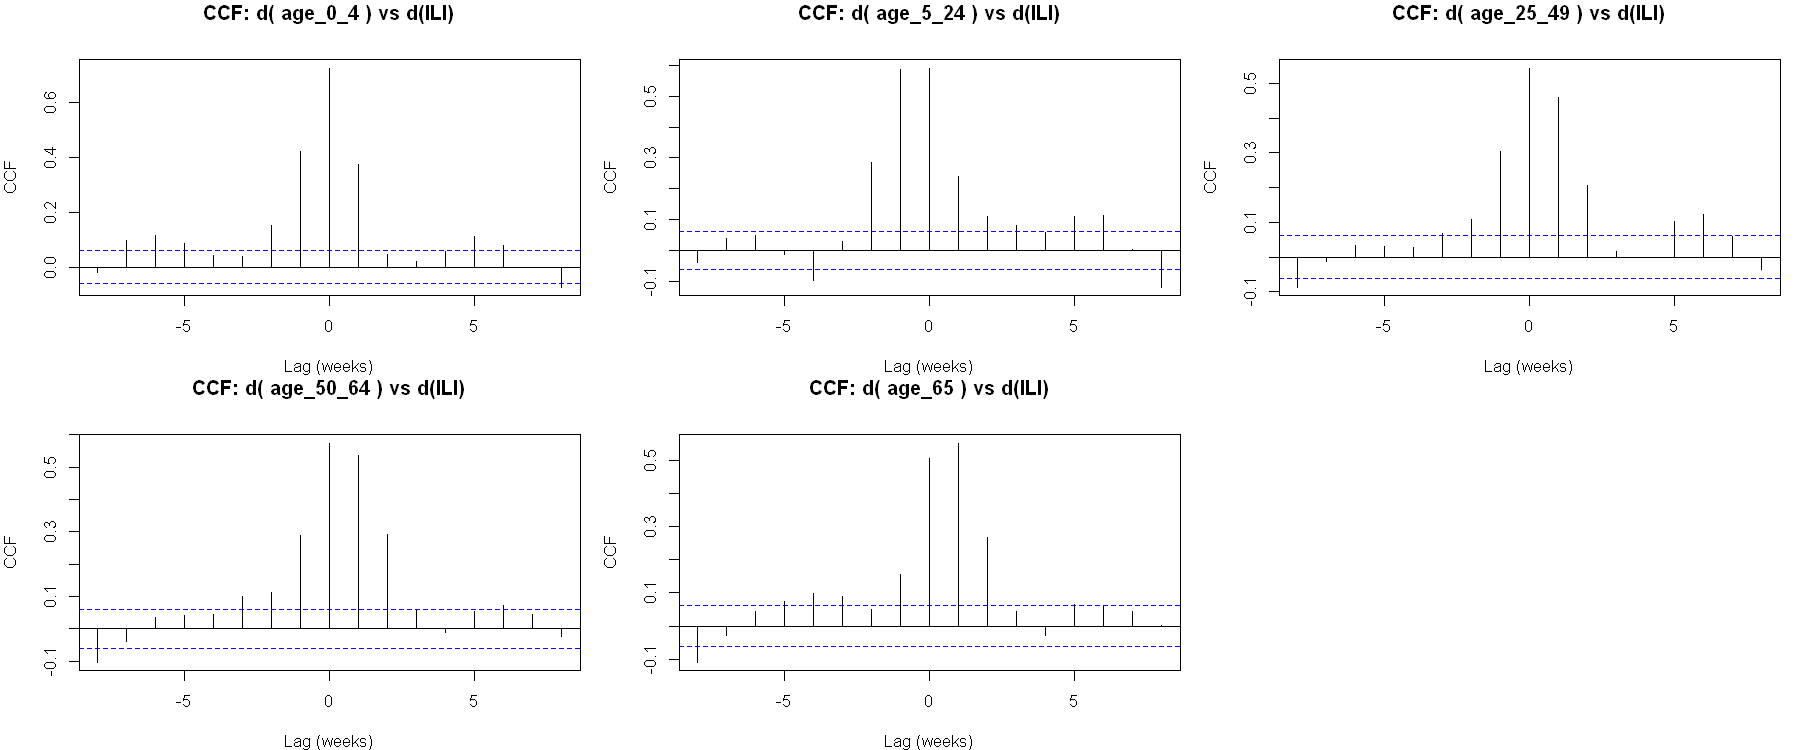

In [5]:
# Difference both ILI and age-group series to remove trend/seasonality before CCF
y_diff    <- diff(df$percent_weighted_ili)
age_cols  <- c("age_0_4", "age_5_24", "age_25_49", "age_50_64", "age_65")

par(mfrow = c(2, 3), mar = c(4, 4, 3, 1))
for (col in age_cols) {
  x_diff <- diff(df[[col]])
  # Remove NAs that may appear from differencing integer columns
  valid  <- !is.na(x_diff) & !is.na(y_diff)
  ccf(x_diff[valid], y_diff[valid],
      lag.max = 8,
      main    = paste("CCF: d(", col, ") vs d(ILI)"),
      ylab    = "CCF", xlab    = "Lag (weeks)")
  abline(h = 0, lty = 2)
}

# Interpretation guide:
# Negative lags mean the age-group LEADS ILI — those are useful predictors.
# Positive lags mean ILI leads the age-group — not useful for forecasting.

In [6]:
# NEW: Pick the age-group covariate with the highest absolute CCF at lag -1
age_cols <- c("age_0_4", "age_5_24", "age_25_49", "age_50_64", "age_65")
y_diff   <- diff(df$percent_weighted_ili)

ccf_lag1 <- sapply(age_cols, function(col) {
  x_diff <- diff(df[[col]])
  valid  <- !is.na(x_diff) & !is.na(y_diff)
  ccf_out <- ccf(x_diff[valid], y_diff[valid],
                 lag.max = 1, plot = FALSE)
  # lag = -1 means the age group leads ILI by 1 week
  ccf_out$acf[ccf_out$lag == -1]
})

ccf_lag1_df <- data.frame(
  age_group   = age_cols,
  ccf_at_lag1 = as.numeric(ccf_lag1)
) %>% arrange(desc(abs(ccf_at_lag1)))

print(ccf_lag1_df)

best_age <- ccf_lag1_df$age_group[1]
cat("Best leading covariate at lag -1:", best_age, "\n")

  age_group ccf_at_lag1
1  age_5_24   0.5854408
2   age_0_4   0.4216809
3 age_25_49   0.3039506
4 age_50_64   0.2875333
5    age_65   0.1561863
Best leading covariate at lag -1: age_5_24 


In [7]:
# Based on the CCF plots, pick the best lag for each age group.
# A value of 1 means: use last week's count to predict this week's ILI.
# Edit after inspecting the CCF plots above.
CHOSEN_LAG <- 1

# Build a tsibble with lagged, differenced covariates.
# df is already a tsibble (created in Section 1), so we just mutate directly.
df_lagged <- df %>%
  mutate(
    d_age_0_4_lag1   = difference(lag(age_0_4,   CHOSEN_LAG)),
    d_age_5_24_lag1  = difference(lag(age_5_24,  CHOSEN_LAG)),
    d_age_25_49_lag1 = difference(lag(age_25_49, CHOSEN_LAG)),
    d_age_50_64_lag1 = difference(lag(age_50_64, CHOSEN_LAG)),
    d_age_65_lag1    = difference(lag(age_65,    CHOSEN_LAG))
  ) %>%
  # Drop the early rows where lags/differences produce NAs
  filter(!is.na(d_age_0_4_lag1)) %>%
  fill_gaps() %>%
  tidyr::fill(
    percent_weighted_ili,
    d_age_0_4_lag1, d_age_5_24_lag1,
    d_age_25_49_lag1, d_age_50_64_lag1, d_age_65_lag1,
    .direction = "down"
  )

cat("Rows after lagging:", nrow(df_lagged), "\n")

Rows after lagging: 1042 


## 3) Train / holdout split
Holdout includes last 104 weeks (2 flu seasons)

In [8]:
HOLDOUT_WEEKS <- 104
n_total       <- nrow(df_lagged)
n_train_init  <- n_total - HOLDOUT_WEEKS

train_full <- df_lagged[1:n_train_init, ]
holdout    <- df_lagged[(n_train_init + 1):n_total, ]

cat("Initial training rows:", nrow(train_full), "\n")
cat("Holdout rows:         ", nrow(holdout),    "\n")
cat("Holdout range:        ", as.character(min(holdout$week_start)),
    "to", as.character(max(holdout$week_start)), "\n")

Initial training rows: 938 
Holdout rows:          104 
Holdout range:         2020 W02 to 2021 W52 


## 4) Rolling one-step-ahead evaluation

For each holdout week `t`:
- Train on all data up to week `t-1` (expanding window)
- Forecast week `t`
- Record the forecast and squared error

This matches the evaluation method described in the project proposal.

In [9]:
rolling_rmse <- function(data, model_expr, model_name, min_train = n_train_init) {

  stretched <- data %>%
    stretch_tsibble(.init = min_train, .step = 1)

  rolling_fits <- rlang::inject(
    model(stretched, mod = !!model_expr)
  )

  rolling_fc <- rolling_fits %>%
    forecast(h = 1)

  actuals <- data %>%
    as_tibble() %>%
    select(week_start, actual = percent_weighted_ili)

  results <- rolling_fc %>%
    as_tibble() %>%
    left_join(actuals, by = "week_start") %>%
    mutate(
      model    = model_name,
      forecast = .mean,
      sq_error = (actual - forecast)^2
    ) %>%
    select(model, week_start, actual, forecast, sq_error)

  results
}

In [11]:
cat("Fitting rolling MEAN baseline...\n")
res_mean <- rolling_rmse(
  df_lagged,
  expr(MEAN(percent_weighted_ili)),
  "Mean"
)

cat("Fitting rolling SNAIVE baseline...\n")
res_snaive <- rolling_rmse(
  df_lagged,
  expr(SNAIVE(percent_weighted_ili ~ lag(52))),
  "SNaive"
)

cat("Fitting rolling STL+ETS...\n")
res_ets <- rolling_rmse(
  df_lagged,
  expr(
    decomposition_model(
      STL(percent_weighted_ili ~ season(period = 52)),
      ETS(season_adjust ~ error("A") + trend("Ad")))
  ),
  "STL+ETS"
)

Fitting rolling MEAN baseline...
Fitting rolling SNAIVE baseline...
Fitting rolling STL+ETS...


Warning message:
"Seasonal periods (`period`) of length greather than 24 are not supported by
ETS. Seasonality will be ignored."
Warning message:
"Seasonal periods (`period`) of length greather than 24 are not supported by
ETS. Seasonality will be ignored."
Warning message:
"Seasonal periods (`period`) of length greather than 24 are not supported by
ETS. Seasonality will be ignored."
Warning message:
"Seasonal periods (`period`) of length greather than 24 are not supported by
ETS. Seasonality will be ignored."
Warning message:
"Seasonal periods (`period`) of length greather than 24 are not supported by
ETS. Seasonality will be ignored."
Warning message:
"Seasonal periods (`period`) of length greather than 24 are not supported by
ETS. Seasonality will be ignored."
Warning message:
"Seasonal periods (`period`) of length greather than 24 are not supported by
ETS. Seasonality will be ignored."
Warning message:
"Seasonal periods (`period`) of length greather than 24 are not supported by
ETS

## 5) ARIMA

In [15]:
cat("Fitting rolling ARIMA...\n")
res_arima <- rolling_rmse(
  df_lagged,
  expr(ARIMA(percent_weighted_ili ~ pdq(2,0,2) + PDQ(2,1,0))),
  "ARIMA"
)

# cat("Fitting rolling ARIMA...\n")
# res_arima <- rolling_rmse(
#   df_lagged,
#   expr(ARIMA(percent_weighted_ili ~ pdq(2,0,2) + PDQ(0,0,0) + 0)),
#   "ARIMA"
# )

Fitting rolling ARIMA...


Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIM

The code below was run once, the ARIMA perturbation:

In [11]:
# ## 4b) ARIMA perturbation comparison
# # The auto-selected model is ARIMA(2,0,2)(2,1,0)[52].
# # We perturb p, q, P, Q by ±1 to confirm it holds up on holdout RMSE.
# # Note: rolling_rmse() uses fable::ARIMA() with fixed orders via pdq()/PDQ().

# # NOTE: THIS CODE IS RAN ONLY ONCE, TOOK A LONG TO RUN SO I SAVED OUTPUT IN THE NEXT CELL BELOW

# arima_candidates <- list(
#   list(label = "ARIMA(2,0,2)(2,1,0) — auto",  p=2, d=0, q=2, P=2, D=1, Q=0),
#   list(label = "ARIMA(2,0,1)(2,1,0)",          p=2, d=0, q=1, P=2, D=1, Q=0),
#   list(label = "ARIMA(2,0,2)(1,1,0)",          p=2, d=0, q=2, P=1, D=1, Q=0),
#   list(label = "ARIMA(1,0,2)(2,1,0)",          p=1, d=0, q=2, P=2, D=1, Q=0),
#   list(label = "ARIMA(2,0,2)(2,1,1)",          p=2, d=0, q=2, P=2, D=1, Q=1),
#   list(label = "ARIMA(3,0,2)(2,1,0)",          p=3, d=0, q=2, P=2, D=1, Q=0)
# )

# arima_perturb_results <- purrr::map_dfr(arima_candidates, function(cand) {
#   cat("Fitting", cand$label, "...\n")
#   res <- rolling_rmse(
#     df_lagged,
#     expr(ARIMA(percent_weighted_ili ~
#            pdq(!!cand$p, !!cand$d, !!cand$q) +
#            PDQ(!!cand$P, !!cand$D, !!cand$Q))),
#     cand$label
#   )
#   res %>%
#     filter(week_start %in% holdout$week_start) %>%
#     summarise(
#       model = first(model),
#       RMSE  = sqrt(mean(sq_error, na.rm = TRUE)),
#       n     = sum(!is.na(sq_error))
#     )
# })

# # Also pull AIC from training-set fits for the same candidates
# arima_aic <- purrr::map_dfr(arima_candidates, function(cand) {
#   fit <- train_full %>%
#     model(mod = ARIMA(percent_weighted_ili ~
#                         pdq(!!cand$p, !!cand$d, !!cand$q) +
#                         PDQ(!!cand$P, !!cand$D, !!cand$Q)))
#   tibble(
#     model = cand$label,
#     AIC   = glance(fit)$AIC
#   )
# })

# arima_perturb_table <- arima_perturb_results %>%
#   left_join(arima_aic, by = "model") %>%
#   arrange(RMSE) %>%
#   mutate(across(where(is.numeric), ~round(., 3)))

# # print(arima_perturb_table)

In [12]:
## 4b) ARIMA perturbation comparison — results hardcoded (pre-run)
arima_perturb_table <- tibble::tribble(
  ~model,                            ~RMSE,  ~n,   ~AIC,
  "ARIMA(2,0,2)(2,1,0) — auto",      0.343,  99,   380,
  "ARIMA(2,0,2)(1,1,0)",             0.377,  104,  417,
  "ARIMA(1,0,2)(2,1,0)",             0.391,  57,   NA,
  "ARIMA(2,0,1)(2,1,0)",             0.403,  48,   379,
  "ARIMA(2,0,2)(2,1,1)",             NaN,    0,    NA,
  "ARIMA(3,0,2)(2,1,0)",             NaN,    0,    NA
)

print(arima_perturb_table)

# A tibble: 6 × 4
  model                         RMSE     n   AIC
  <chr>                        <dbl> <dbl> <dbl>
1 ARIMA(2,0,2)(2,1,0) — auto   0.343    99   380
2 ARIMA(2,0,2)(1,1,0)          0.377   104   417
3 ARIMA(1,0,2)(2,1,0)          0.391    57    NA
4 ARIMA(2,0,1)(2,1,0)          0.403    48   379
5 ARIMA(2,0,2)(2,1,1)        NaN         0    NA
6 ARIMA(3,0,2)(2,1,0)        NaN         0    NA


**Results**:
| Model                      | RMSE  | n   | AIC |
|----------------------------|-------|-----|-----|
| ARIMA(2,0,2)(2,1,0) — auto | 0.343 | 99  | 380 |
| ARIMA(2,0,2)(1,1,0)        | 0.377 | 104 | 417 |
| ARIMA(1,0,2)(2,1,0)        | 0.391 | 57  | NA  |
| ARIMA(2,0,1)(2,1,0)        | 0.403 | 48  | 379 |
| ARIMA(2,0,2)(2,1,1)        | NaN   | 0   | NA  |
| ARIMA(3,0,2)(2,1,0)        | NaN   | 0   | NA  |

## 5) ARIMAX with lagged age group covariates

In [13]:
# Rolling ARIMAX using base arima() — matches the rubric's armax_fc() approach
rolling_arimax_base <- function(data, covariate_col, 
                                 order = c(2,0,1), seasonal = list(order=c(1,1,0), period=52),
                                 min_train = n_train_init) {
  df_tb <- as_tibble(data)
  n <- nrow(df_tb)
  forecasts <- rep(NA_real_, n)
  
  for (t in (min_train + 1):n) {
    train_y  <- df_tb$percent_weighted_ili[1:(t-1)]
    train_x  <- df_tb[[covariate_col]][1:(t-1)]
    new_x    <- df_tb[[covariate_col]][t]  # covariate is already lagged, so this is valid
    
    fit <- tryCatch(
      arima(train_y, order = order, seasonal = seasonal, xreg = as.matrix(train_x)),
      error = function(e) NULL
    )
    if (!is.null(fit)) {
      forecasts[t] <- predict(fit, n.ahead = 1, newxreg = as.matrix(new_x))$pred[1]
    }
  }
  
  tibble(
    model     = "ARIMAX",
    week_start = df_tb$week_start,
    actual    = df_tb$percent_weighted_ili,
    forecast  = forecasts
  ) %>%
    filter(!is.na(forecast)) %>%
    mutate(sq_error = (actual - forecast)^2)
}

res_arimax <- rolling_arimax_base(df_lagged, covariate_col = "d_age_5_24_lag1")

## 6) RMSE comparison table

In [16]:
all_results <- bind_rows(
  res_mean, res_snaive, res_ets, res_arima, res_arimax
) %>%
  filter(week_start %in% holdout$week_start)

rmse_table <- all_results %>%
  group_by(model) %>%
  summarise(
    RMSE = sqrt(mean(sq_error, na.rm = TRUE)),
    n    = sum(!is.na(sq_error)),
    .groups = "drop"
  ) %>%
  arrange(RMSE) %>%
  mutate(RMSE = round(RMSE, 3))

print(rmse_table)

# A tibble: 5 × 3
  model    RMSE     n
  <chr>   <dbl> <int>
1 ARIMA   0.343    99
2 ARIMAX  0.356   104
3 STL+ETS 0.376   104
4 Mean    1.53    104
5 SNaive  2.06    104


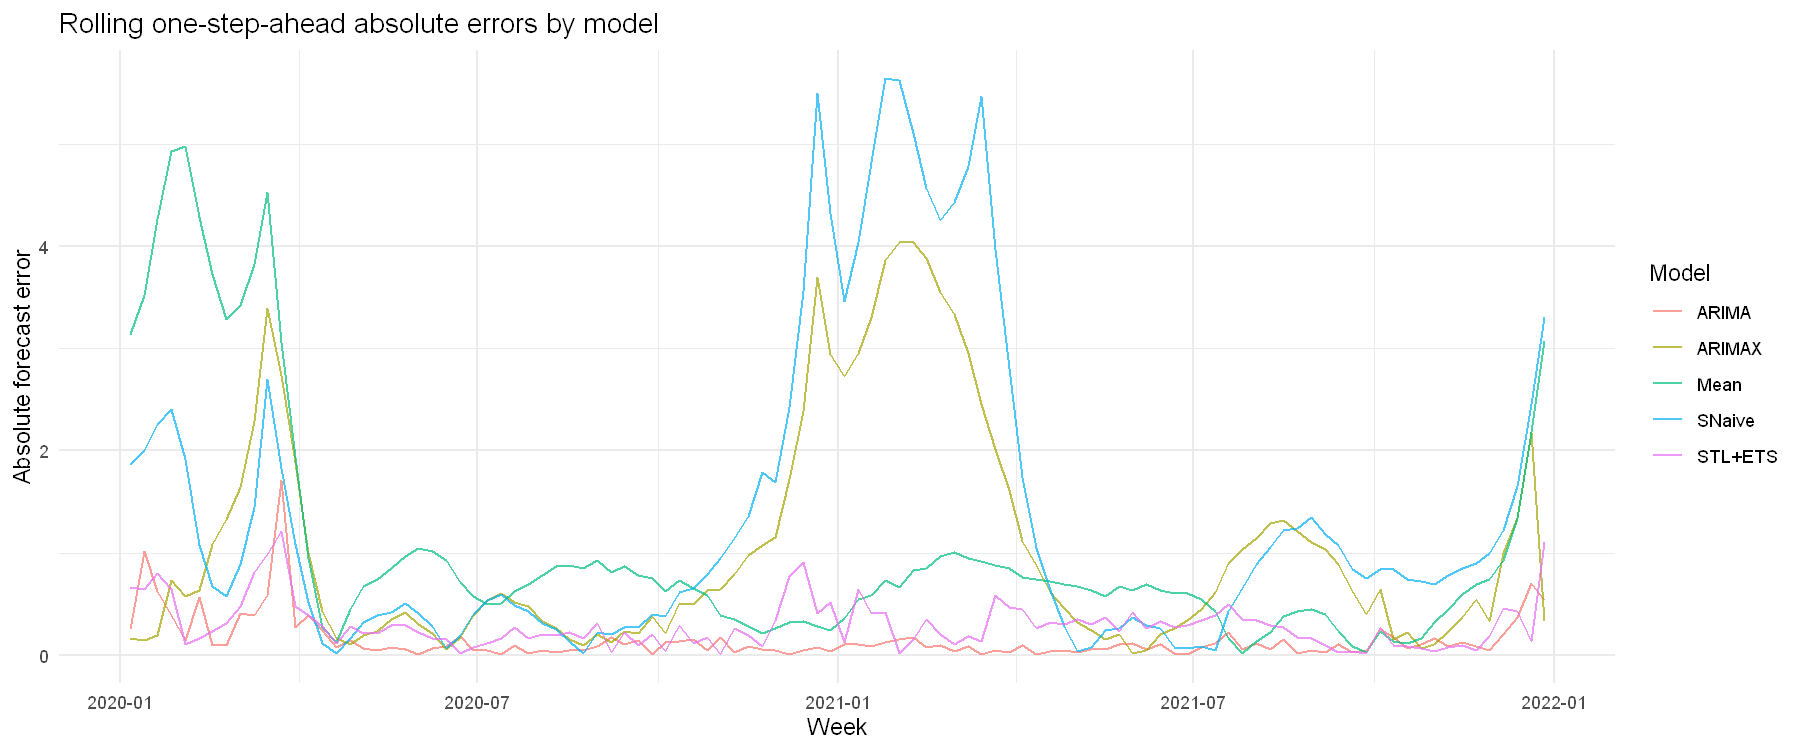

In [20]:
# Plot: rolling squared errors over time for each model
all_results %>%
  filter(week_start %in% holdout$week_start) %>%
  ggplot(aes(x = as.Date(week_start), y = sqrt(sq_error), color = model)) +
  geom_line(alpha = 0.7) +
  labs(
    title = "Rolling one-step-ahead absolute errors by model",
    x     = "Week",
    y     = "Absolute forecast error",
    color = "Model"
  ) +
  theme_minimal()

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."


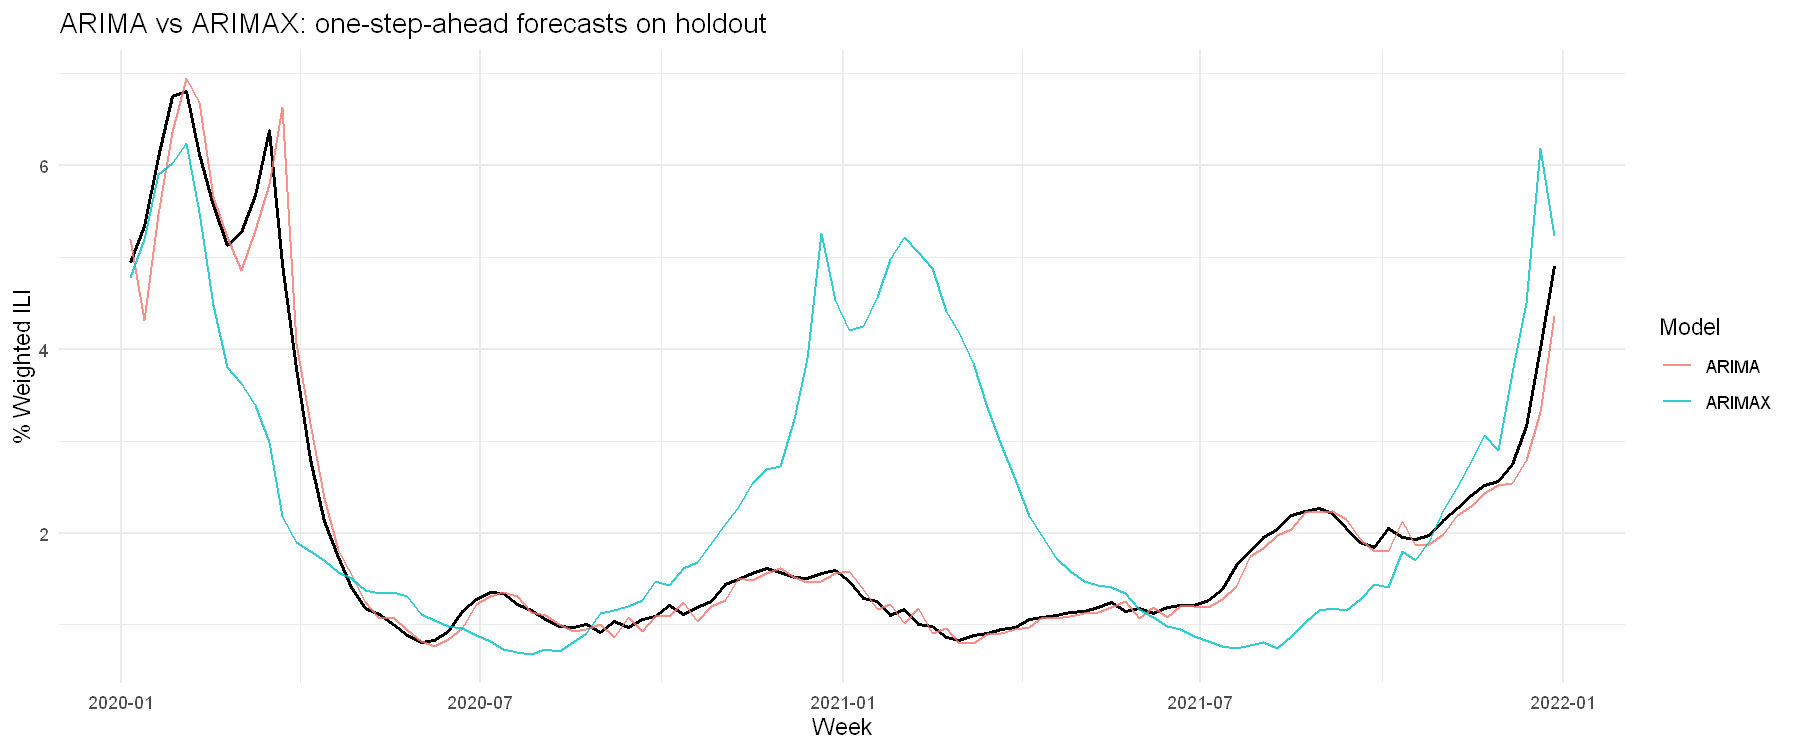

In [21]:
# Plot: ARIMA and ARIMAX forecasts vs actual over holdout
all_results %>%
  filter(
    week_start %in% holdout$week_start,
    model %in% c("ARIMA", "ARIMAX")
  ) %>%
  ggplot(aes(x = as.Date(week_start))) +
  geom_line(aes(y = actual), color = "black", size = 0.8) +
  geom_line(aes(y = forecast, color = model), alpha = 0.8) +
  labs(
    title = "ARIMA vs ARIMAX: one-step-ahead forecasts on holdout",
    x     = "Week",
    y     = "% Weighted ILI",
    color = "Model"
  ) +
  theme_minimal()

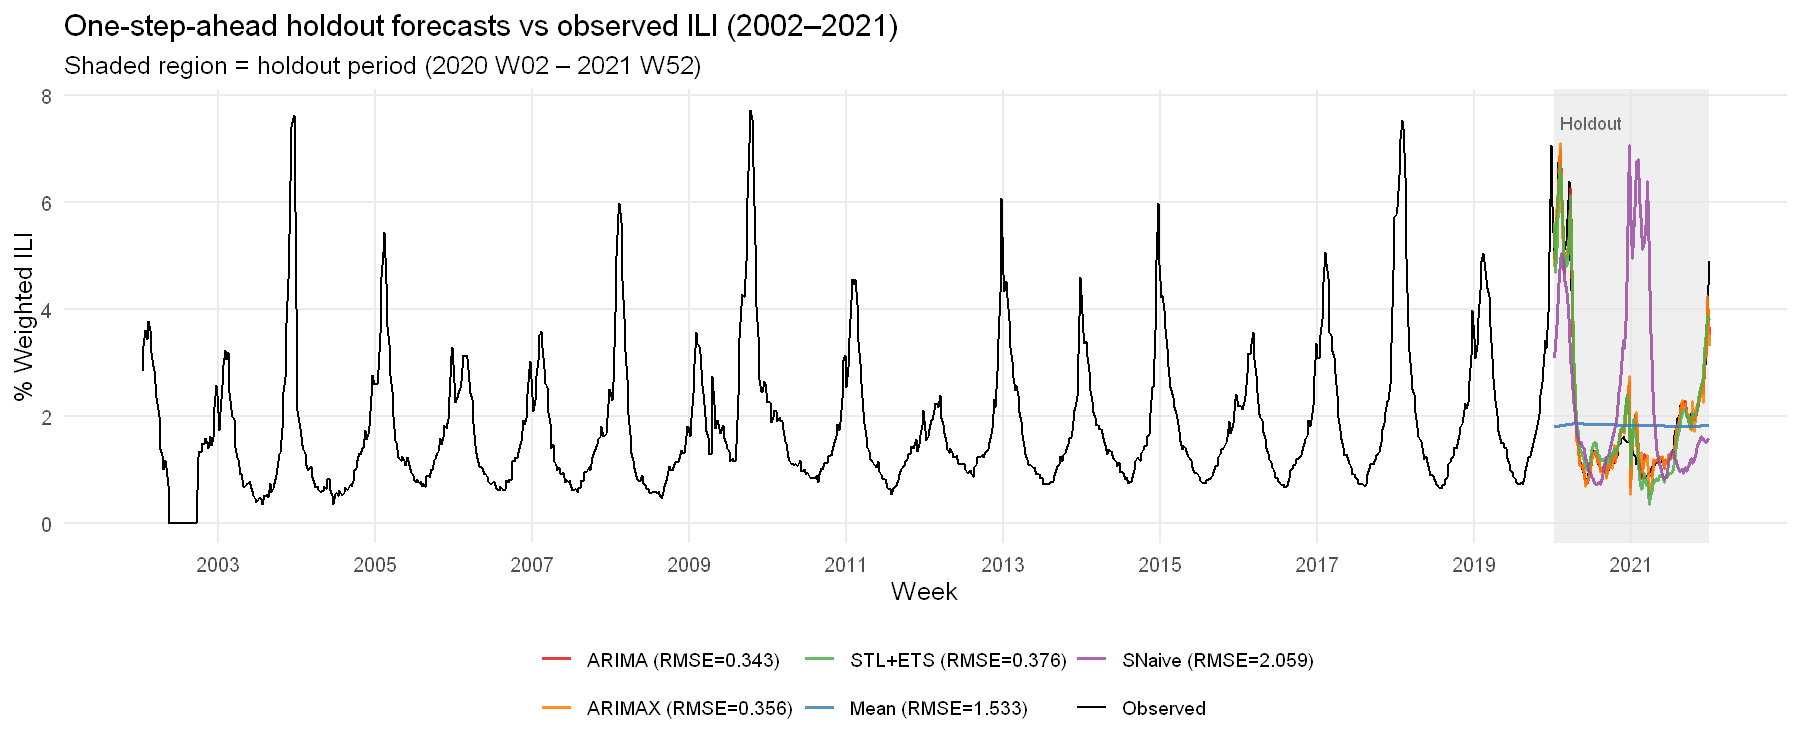

In [17]:
# ── Forecast comparison plot ────────────────────────────────────────────────
# Assumes in your environment:
#   res_mean, res_snaive, res_ets, res_arima  — from rolling_rmse()
#   res_arimax                                — tibble with model/week_start/actual/forecast
#   df_lagged                                 — full tsibble (training + holdout)
#   holdout                                   — holdout tsibble

# 1) Observed series (full 2002–2021)
observed <- df_lagged %>%
  as_tibble() %>%
  select(week_start, percent_weighted_ili) %>%
  mutate(week_start = as.Date(week_start))

# 2) Stack all forecast results into one long tibble
all_forecasts <- bind_rows(
  res_mean   %>% as_tibble() %>% select(model, week_start, forecast),
  res_snaive %>% as_tibble() %>% select(model, week_start, forecast),
  res_ets    %>% as_tibble() %>% select(model, week_start, forecast),
  res_arima  %>% as_tibble() %>% select(model, week_start, forecast),
  res_arimax %>% as_tibble() %>% select(model, week_start, forecast)
) %>%
  mutate(week_start = as.Date(week_start)) %>%
  filter(week_start %in% as.Date(holdout$week_start))

# 3) RMSE labels for the legend
rmse_labels <- rmse_table %>%
  mutate(label = paste0(model, " (RMSE=", round(RMSE, 3), ")")) %>%
  select(model, label)

all_forecasts <- all_forecasts %>%
  left_join(rmse_labels, by = "model") %>%
  mutate(label = factor(label, levels = rmse_labels$label))  # order by RMSE rank

# 4) Holdout shading boundary
holdout_start <- as.Date(min(holdout$week_start))

# 5) Plot
pal <- c(
  "black",       # observed
  "#E41A1C",     # MEAN
  "#FF7F00",     # SNaive
  "#4DAF4A",     # STL+ETS
  "#377EB8",     # ARIMA
  "#984EA3"      # ARIMAX
)

ggplot() +
  # Holdout shading
  annotate("rect",
    xmin = holdout_start, xmax = as.Date(max(observed$week_start)),
    ymin = -Inf, ymax = Inf,
    fill = "grey90", alpha = 0.6
  ) +
  annotate("text",
    x = holdout_start + 30, y = max(observed$percent_weighted_ili, na.rm = TRUE) * 0.97,
    label = "Holdout", size = 3, color = "grey40", hjust = 0
  ) +
  # Observed
  geom_line(
    data = observed,
    aes(x = week_start, y = percent_weighted_ili, color = "Observed"),
    linewidth = 0.6
  ) +
  # Forecasts
  geom_line(
    data = all_forecasts,
    aes(x = week_start, y = forecast, color = label),
    linewidth = 0.7, alpha = 0.85
  ) +
  scale_color_manual(
    name   = NULL,
    values = setNames(pal, c("Observed", levels(all_forecasts$label)))
  ) +
  scale_x_date(date_breaks = "2 years", date_labels = "%Y") +
  labs(
    title    = "One-step-ahead holdout forecasts vs observed ILI (2002–2021)",
    subtitle = "Shaded region = holdout period (2020 W02 – 2021 W52)",
    x        = "Week",
    y        = "% Weighted ILI"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position  = "bottom",
    legend.text      = element_text(size = 9),
    panel.grid.minor = element_blank()
  ) +
  guides(color = guide_legend(nrow = 2))

## 7) Residual diagnostics

In [22]:
# Fit on full training set
fit_final <- train_full %>%
  model(
    ARIMA  = ARIMA(percent_weighted_ili),
    ARIMAX = ARIMA(percent_weighted_ili ~
      d_age_0_4_lag1 + d_age_5_24_lag1 +
      d_age_25_49_lag1 + d_age_50_64_lag1 + d_age_65_lag1)
  )

# Print selected orders
cat("ARIMA order:\n")
fit_final %>% select(ARIMA) %>% report()

cat("\nARIMAX order:\n")
fit_final %>% select(ARIMAX) %>% report()

Warning message in sqrt(diag(best$var.coef)):
"NaNs produced"


ARIMA order:
Series: percent_weighted_ili 
Model: ARIMA(2,0,2)(2,1,0)[52] 

Coefficients:
         ar1      ar2     ma1      ma2     sar1     sar2
      1.6452  -0.7058  -0.346  -0.0408  -0.6183  -0.2340
s.e.  0.0718   0.0647   0.081   0.0510   0.0346   0.0372

sigma^2 estimated as 0.08681:  log likelihood=-183.24
AIC=380.49   AICc=380.61   BIC=413.99

ARIMAX order:
Series: percent_weighted_ili 
Model: LM w/ ARIMA(2,0,1)(1,1,0)[52] errors 

Coefficients:
         ar1      ar2      ma1     sar1  d_age_0_4_lag1  d_age_5_24_lag1
      1.6773  -0.7328  -0.4102  -0.5143               0                0
s.e.  0.0103   0.0191      NaN   0.0312               0              NaN
      d_age_25_49_lag1  d_age_50_64_lag1  d_age_65_lag1
                     0                 0         -1e-04
s.e.                 0                 0          1e-04

sigma^2 estimated as 0.08607:  log likelihood=-175.54
AIC=371.09   AICc=371.34   BIC=418.95


In [23]:
fit_arima_full <- train_full %>%
  model(ARIMA = ARIMA(percent_weighted_ili))

cat("ARIMA order:\n")
fit_arima_full %>% report()

ARIMA order:
Series: percent_weighted_ili 
Model: ARIMA(2,0,2)(2,1,0)[52] 

Coefficients:
         ar1      ar2     ma1      ma2     sar1     sar2
      1.6452  -0.7058  -0.346  -0.0408  -0.6183  -0.2340
s.e.  0.0718   0.0647   0.081   0.0510   0.0346   0.0372

sigma^2 estimated as 0.08681:  log likelihood=-183.24
AIC=380.49   AICc=380.61   BIC=413.99


In [24]:
fit_arimax_full <- train_full %>%
  model(
    ARIMAX = ARIMA(percent_weighted_ili ~
      d_age_0_4_lag1 + d_age_5_24_lag1 +
      d_age_25_49_lag1 + d_age_50_64_lag1 + d_age_65_lag1 +
      pdq(0:2, 0:1, 0:2) + PDQ(0:2, 1, 0))  # seasonal structure from ARIMA
  )

cat("ARIMAX order:\n")
fit_arimax_full %>% report()

Warning message in sqrt(diag(best$var.coef)):
"NaNs produced"


ARIMAX order:
Series: percent_weighted_ili 
Model: LM w/ ARIMA(2,0,1)(1,1,0)[52] errors 

Coefficients:
         ar1      ar2      ma1     sar1  d_age_0_4_lag1  d_age_5_24_lag1
      1.6773  -0.7328  -0.4102  -0.5143               0                0
s.e.  0.0103   0.0191      NaN   0.0312               0              NaN
      d_age_25_49_lag1  d_age_50_64_lag1  d_age_65_lag1
                     0                 0         -1e-04
s.e.                 0                 0          1e-04

sigma^2 estimated as 0.08607:  log likelihood=-175.54
AIC=371.09   AICc=371.34   BIC=418.95


**Conclusion from ARIMAX:**

From the output, we see that ARIMAX beats ARIMA in AIC. This can suggest that age-group lagged differences can contain predictive information beyond what ILI series already captures.

Warning message:
"`gg_tsresiduals()` was deprecated in feasts 0.4.2.
ℹ Please use `ggtime::gg_tsresiduals()` instead.
ℹ Graphics functions have been moved to the {ggtime} package. Please use
  `library(ggtime)` instead."


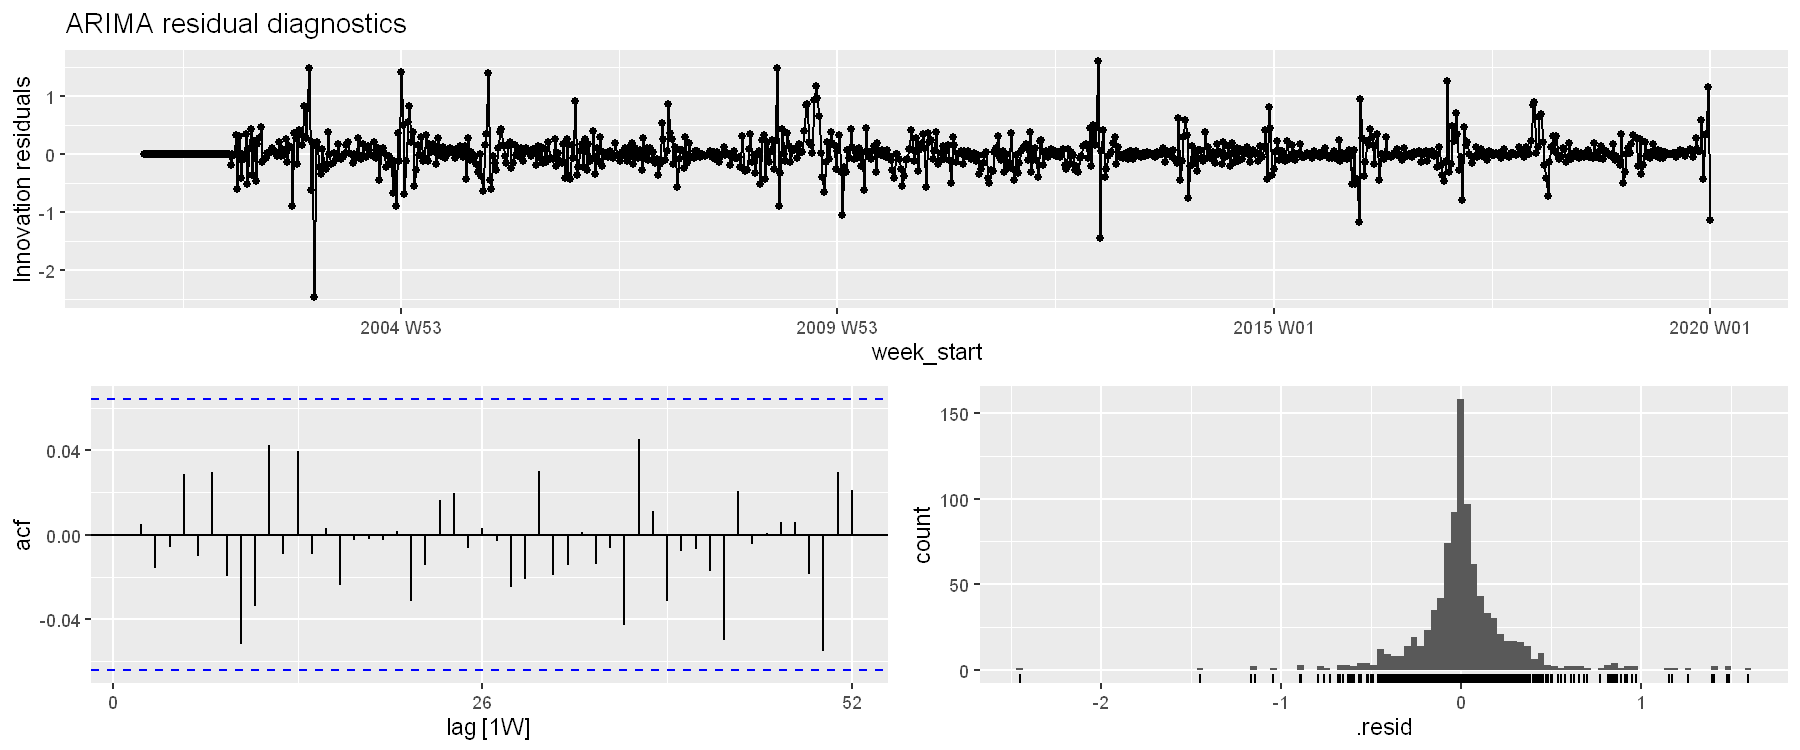

In [25]:
# # Residual plots — gg_tsresiduals shows time plot, ACF, and histogram
# fit_final %>%
#   select(ARIMA) %>%
#   gg_tsresiduals(lag_max = 52) +
#   labs(title = "ARIMA residual diagnostics")

fit_arima_full %>%
  gg_tsresiduals(lag_max = 52) +
  labs(title = "ARIMA residual diagnostics")

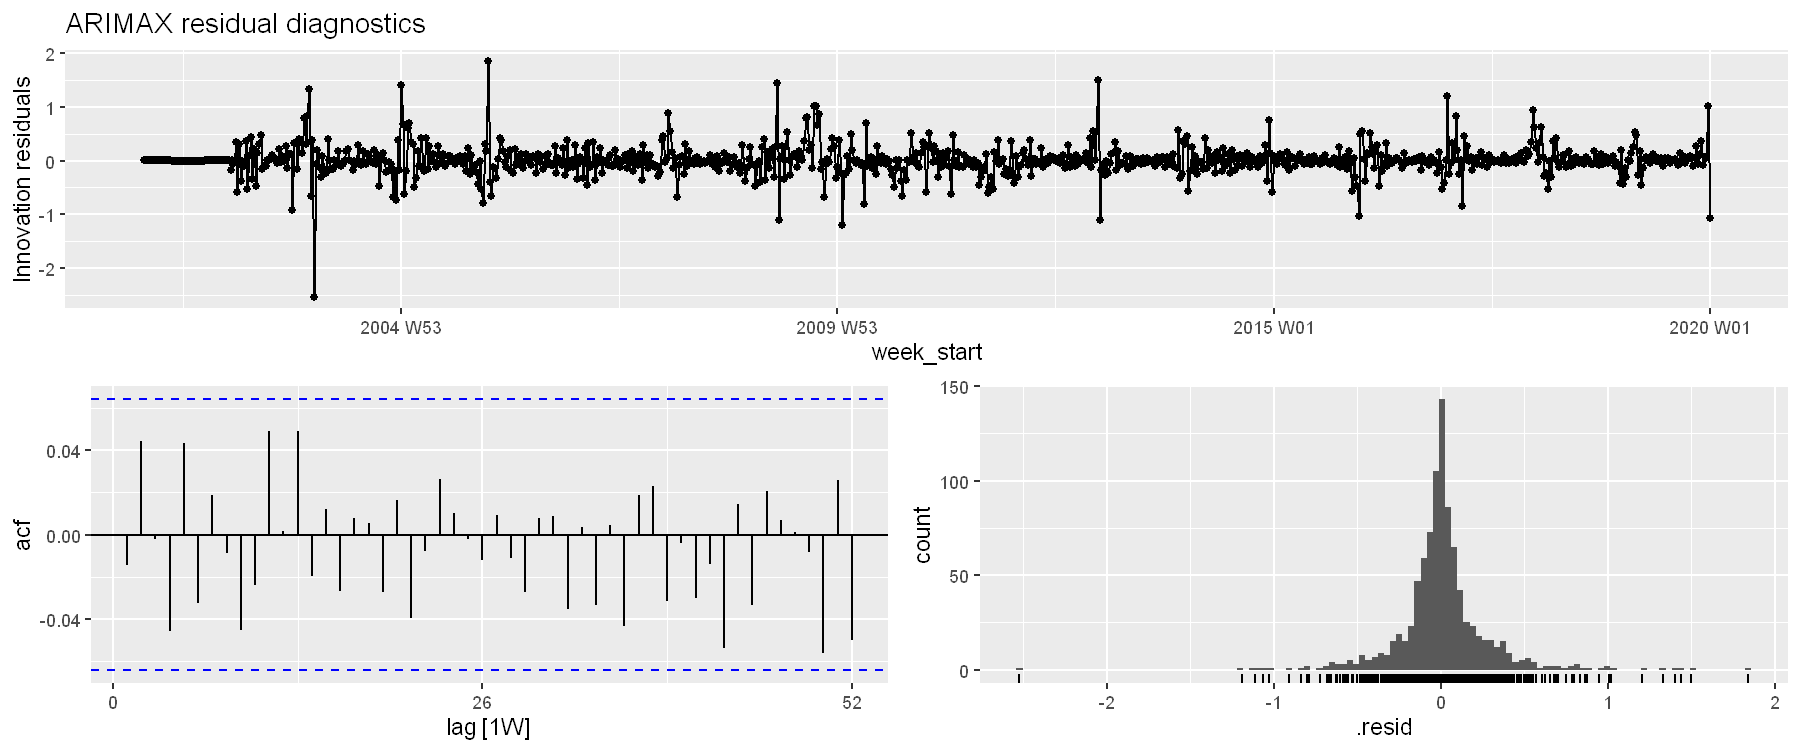

In [26]:
# fit_final %>%
#   select(ARIMAX) %>%
#   gg_tsresiduals(lag_max = 52) +
#   labs(title = "ARIMAX residual diagnostics")

fit_arimax_full %>%
  gg_tsresiduals(lag_max = 52) +
  labs(title = "ARIMAX residual diagnostics")